# Problem Statement & Objective:

# Problem Statement:
Analyze the Global Superstore Dataset to understand sales performance, profit trends, and customer behavior across different regions and categories.

# Objective:
Build an interactive Streamlit dashboard that:

1. Shows Total Sales & Profit
2. Identifies Top 5 Customers
3. Allows filtering by:
- Region
- Category
- Sub-Category

In [6]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Improve chart style
sns.set_style("whitegrid")

In [9]:
# Load dataset
df = pd.read_csv("superstore.csv")

print(df.head())
print(df.info())

          Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  记录数               Order.Date        Order.ID  ... Sales  \
0       0.0     US    1  2011-01-07 00:00:00.000  CA-2011-130813  ...    19   
1       0.0     US    1  2011-01-21 00:00:00.000  CA-2011-148614  ...    19   
2       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...    21   
3       0.0     US    1  2011-08-05 00:00:00.000  CA-2011-118962  ...   111   
4       0.0     US    1  2011-09-29 00:00:00.000  CA-2011-146969  ...     6   

    Segment                Ship.Date       S

In [10]:
# Dataset Overview

print("\nDataset Shape:", df.shape)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


Dataset Shape: (51290, 27)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  in

In [12]:
# Data Cleaning

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop missing values
df = df.dropna()

# Convert date columns
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])



Missing Values:
Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [13]:
# KPI Calculations

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("\nTotal Sales:", total_sales)
print("Total Profit:", total_profit)


Total Sales: 12642905
Total Profit: 1467457.2912800002


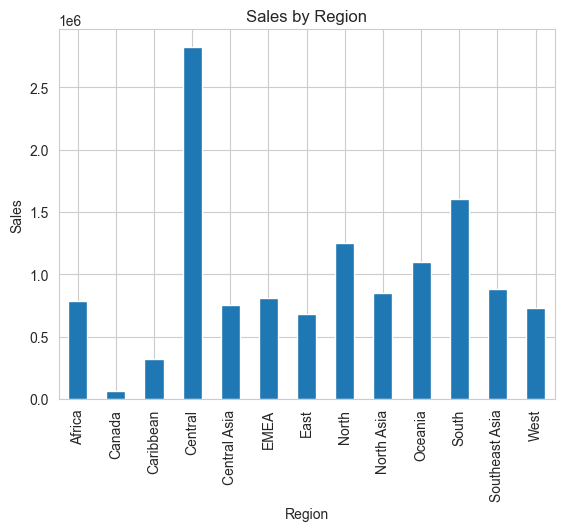

In [14]:
# Sales by Region


sales_region = df.groupby('Region')['Sales'].sum()

plt.figure()
sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

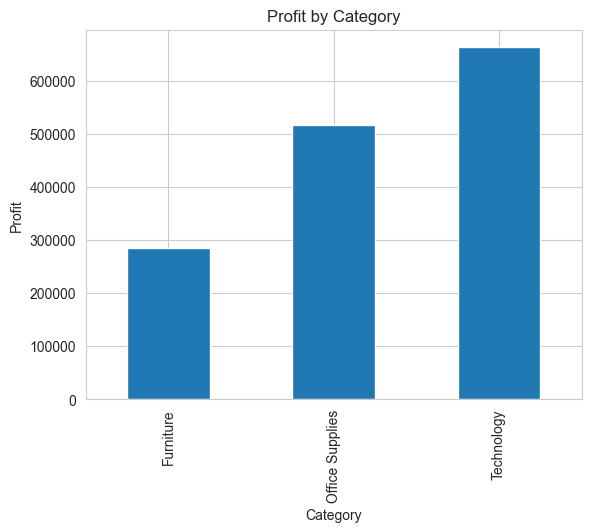

In [15]:
# Profit by Category

profit_category = df.groupby('Category')['Profit'].sum()

plt.figure()
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


Top 5 Customers by Sales:
Customer.Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Name: Sales, dtype: int64


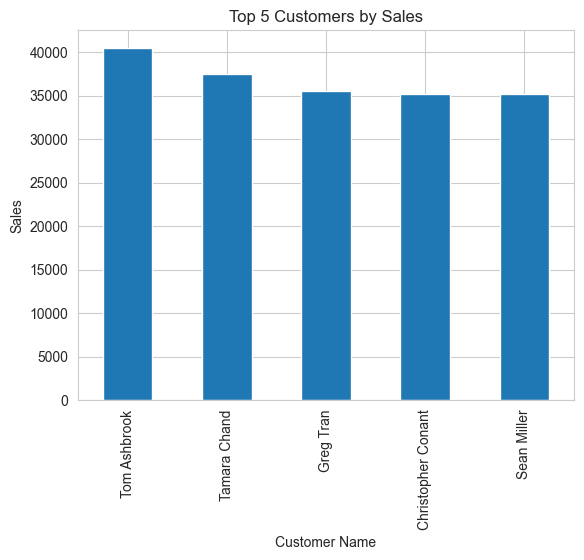

In [17]:
# Top 5 Customers by Sales

top_customers = (
    df.groupby('Customer.Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 Customers by Sales:")
print(top_customers)

plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 5 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.show()

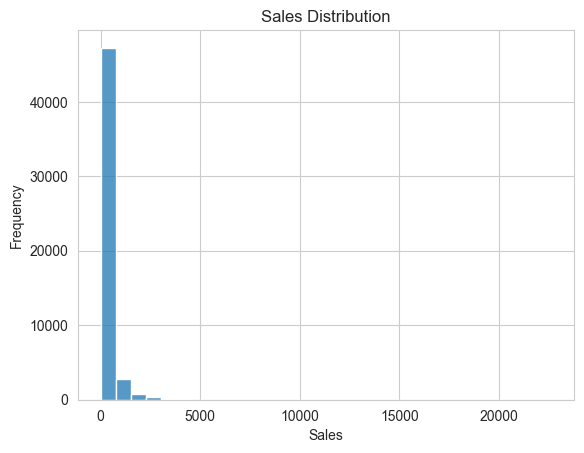

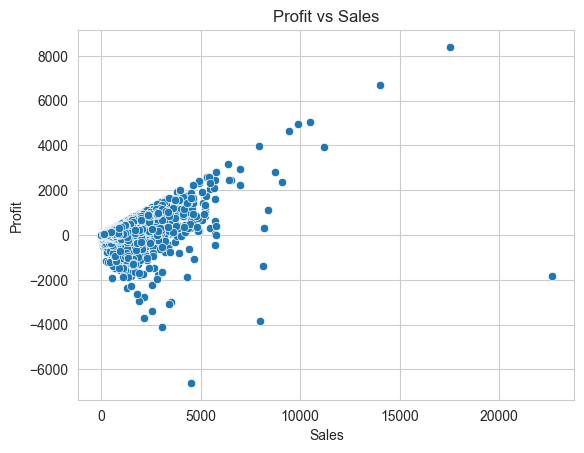

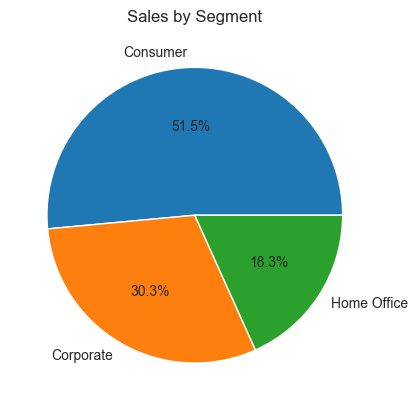

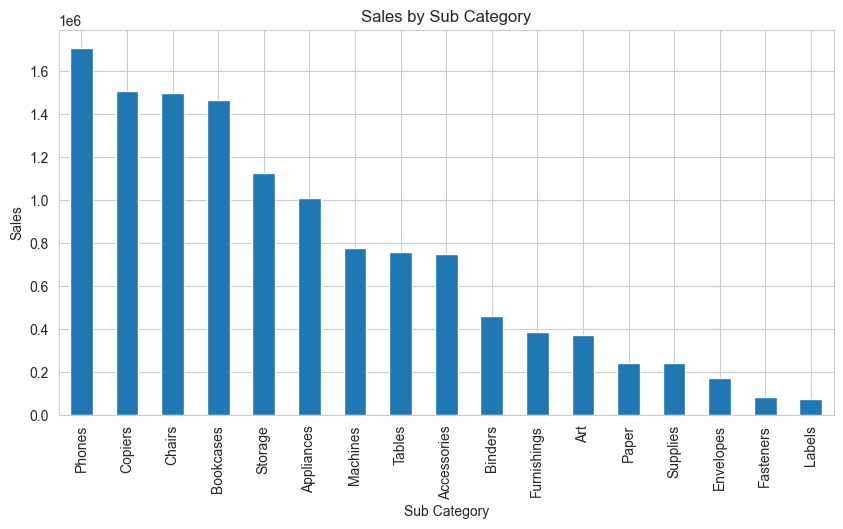

In [18]:
# Sales Distribution

plt.figure()
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Profit vs Sales

plt.figure()
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Profit vs Sales")
plt.show()

# Segment-wise Sales

segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure()
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Segment")
plt.ylabel("")
plt.show()

# Sub Category Sales

subcat_sales = df.groupby('Sub.Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
subcat_sales.plot(kind='bar')
plt.title("Sales by Sub Category")
plt.xlabel("Sub Category")
plt.ylabel("Sales")
plt.show()

## Conclusion

Key Insights:

1. Certain regions generate significantly higher sales.
2. A small number of customers contribute a large portion of revenue.
3. Some categories generate high sales but low profit.
4. Understanding these patterns helps businesses improve marketing strategies.

The Streamlit dashboard allows interactive exploration of these insights.